<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/Multi_Class_Classification_of_Skin_Cancer_Using_EfficientNetB3_on_ISIC_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

base_path = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration"

train_path = os.path.join(base_path, "Train")
test_path = os.path.join(base_path, "Test")

IMG_SIZE = 300
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(class_names)

Found 2239 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [ ]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(2.182261208576998), 1: np.float64(0.6616430260047281), 2: np.float64(2.6187134502923977), 3: np.float64(0.5679857940131913), 4: np.float64(0.6968565203859322), 5: np.float64(0.5384800384800384), 6: np.float64(3.230880230880231), 7: np.float64(1.3744628606507059), 8: np.float64(1.7897681854516387)}


In [ ]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(num_classes, activation='softmax')(x)

model = Model(input_layer, output)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history1 = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 719s 10s/step - accuracy: 0.1536 - loss: 2.7854 - val_accuracy: 0.1864 - val_loss: 2.1465
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 692s 10s/step - accuracy: 0.2412 - loss: 2.3212 - val_accuracy: 0.2119 - val_loss: 2.0555
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 682s 10s/step - accuracy: 0.2814 - loss: 2.1033 - val_accuracy: 0.2034 - val_loss: 1.9790
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 675s 10s/step - accuracy: 0.3176 - loss: 1.9758 - val_accuracy: 0.2966 - val_loss: 1.8595
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 664s 9s/step - accuracy: 0.3216 - loss: 1.8781 - val_accuracy: 0.2966 - val_loss: 1.8257
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 669s 10s/step - accuracy: 0.3381 - loss: 1.8024 - val_accuracy: 0.3220 - val_loss: 1.8091
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 670s 10s/step - accuracy: 0.3805 - loss: 1.7012 - val_accuracy: 0.3559 - val_loss: 1.8210
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 665s 10s/step - accuracy: 0.3703 - loss: 1.6738 - val_accuracy: 0.3

In [ ]:
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.keras", save_best_only=True)
]

In [ ]:
history2 = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2805 - loss: 2.1894 
Epoch 1: val_accuracy improved from 0.08475 to 0.33051, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 908s 12s/step - accuracy: 0.2774 - loss: 2.1673 - val_accuracy: 0.3305 - val_loss: 1.9385 - learning_rate: 1.0000e-06
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2937 - loss: 2.1221 
Epoch 2: val_accuracy did not improve from 0.33051
70/70 ━━━━━━━━━━━━━━━━━━━━ 911s 12s/step - accuracy: 0.2872 - loss: 2.1445 - val_accuracy: 0.3136 - val_loss: 2.0577 - learning_rate: 1.0000e-06
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2768 - loss: 2.1507 
Epoch 3: val_accuracy did not improve from 0.33051
70/70 ━━━━━━━━━━━━━━━━━━━━ 862s 12s/step - accuracy: 0.2827 - loss: 2.1502 - val_accuracy: 0.3220 - val_loss: 2.1355 - learning_rate: 1.0000e-06
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.272

In [ ]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print("Final Accuracy:", acc * 100)
print("="*40)

4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.3305 - loss: 1.9385
Final Accuracy: 33.05084705352783


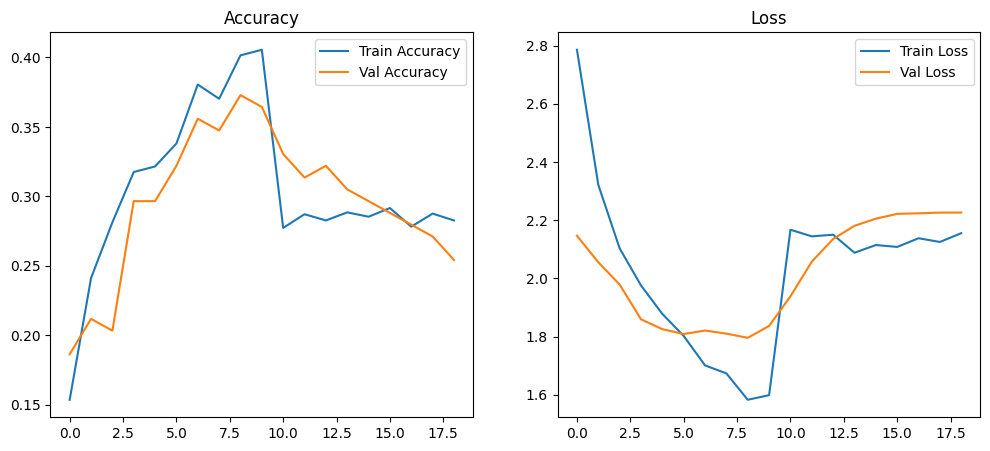

In [ ]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title("Loss")
plt.legend()

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 46s 10s/step


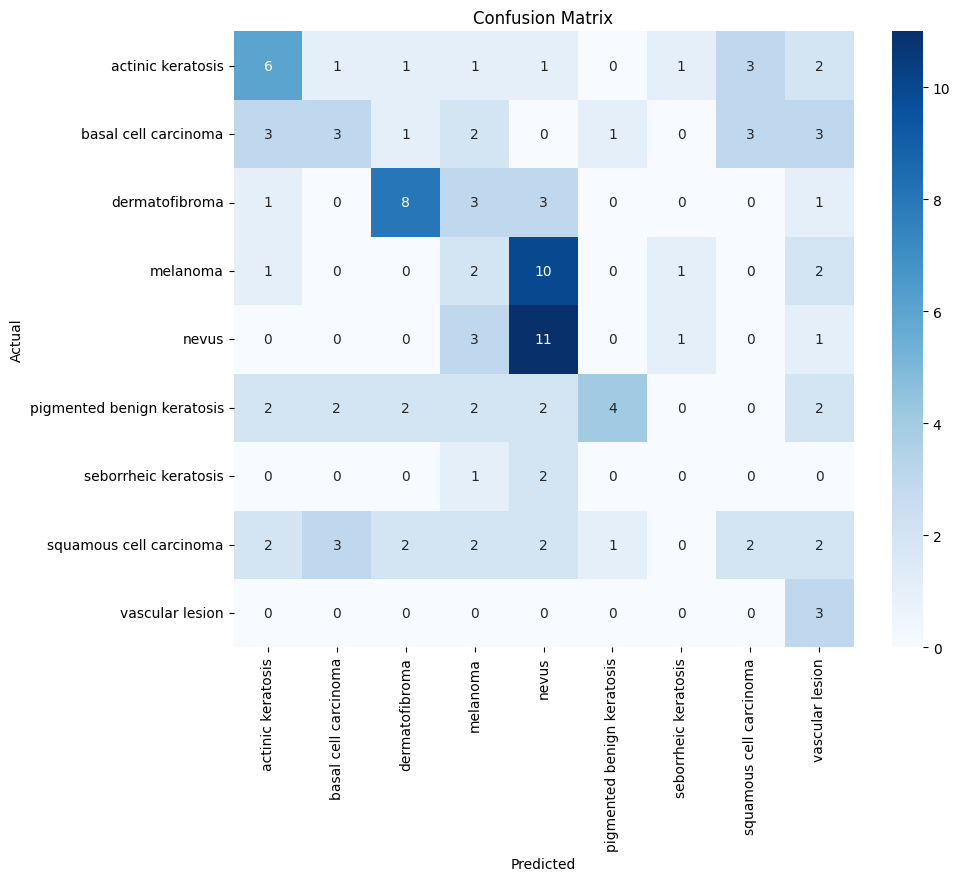

In [ ]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    test_generator.classes,
    y_pred_classes,
    target_names=class_names
))

                            precision    recall  f1-score   support

         actinic keratosis       0.40      0.38      0.39        16
      basal cell carcinoma       0.33      0.19      0.24        16
            dermatofibroma       0.57      0.50      0.53        16
                  melanoma       0.12      0.12      0.12        16
                     nevus       0.35      0.69      0.47        16
pigmented benign keratosis       0.67      0.25      0.36        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.25      0.12      0.17        16
           vascular lesion       0.19      1.00      0.32         3

                  accuracy                           0.33       118
                 macro avg       0.32      0.36      0.29       118
              weighted avg       0.37      0.33      0.32       118



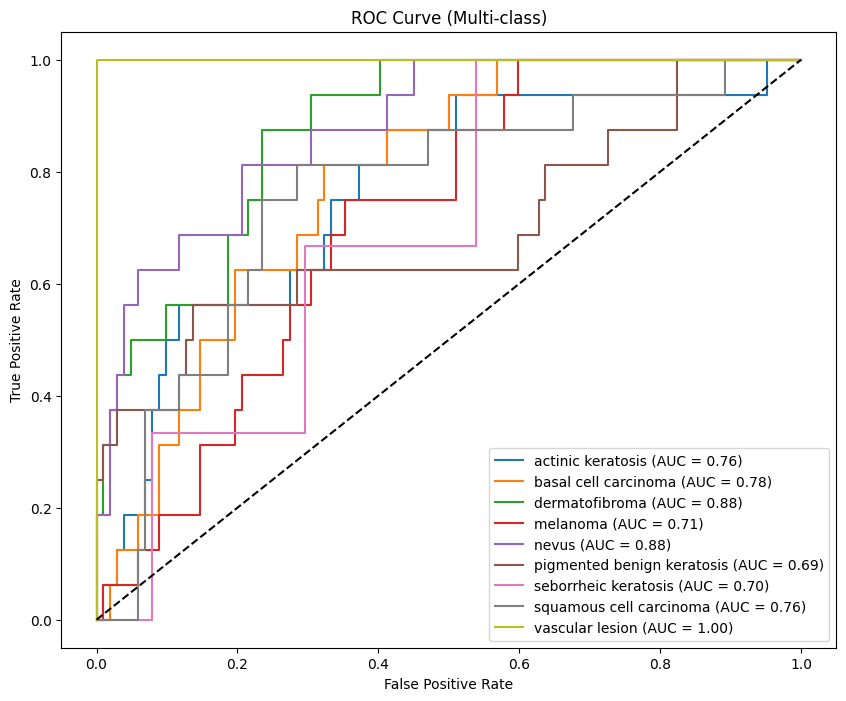

In [ ]:
y_true = label_binarize(test_generator.classes, classes=range(num_classes))
y_score = y_pred

plt.figure(figsize=(10,8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()